## Figure 8: Plot OLR Samples

In [1]:
import autoroot
import matplotlib.pyplot as plt
import os
import numpy as np

In [3]:
samples = np.load(os.path.join(str(autoroot.root), 'data/samples_from_model/OLR_samples_hogncq16.npz'))
olr_samples = samples['olr']
log_probs = samples['log_prob'] / (64*64)

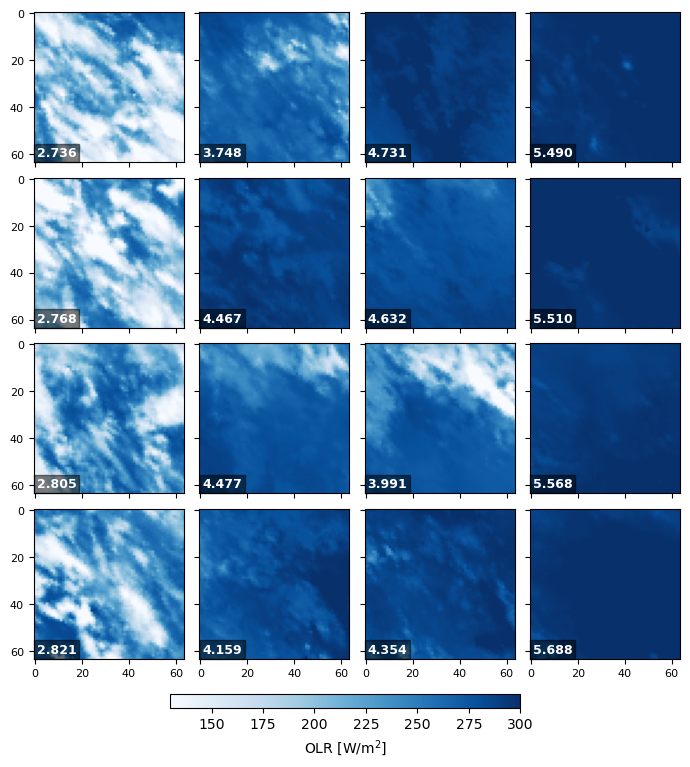

In [4]:
sorted_idx = np.argsort(log_probs)

low_idx  = sorted_idx[:4]        # top row
high_idx = sorted_idx[-4:]       # bottom row

# pool for random rows (exclude low & high)
all_idx = np.arange(len(log_probs))
mask = np.ones_like(all_idx, dtype=bool)
mask[low_idx] = False
mask[high_idx] = False

np.random.seed(21)
rand_idx = np.random.choice(all_idx[mask], 8, replace=False)  # 2 middle rows
rand_row1 = rand_idx[:4]
rand_row2 = rand_idx[4:]

# arrange them row by row in a 4×4 grid
sel_idx = np.concatenate([low_idx, rand_row1, rand_row2, high_idx])

imgs2 = olr_samples[sel_idx, 0]
bps2  = log_probs[sel_idx]


## plot olr samples with bpd annotations
fig2, axes2 = plt.subplots(4, 4, figsize=(7, 7), sharex=True, sharey=True)

vmin2 = 130
vmax2 = 300

for ax, img, bp in zip(axes2.T.flat, imgs2, bps2):
    im2 = ax.imshow(img, cmap="Blues", vmin=vmin2, vmax=vmax2)
    ax.text(
        0.02, 0.04, f"{bp:.3f}",
        transform=ax.transAxes,
        color="white",
        fontweight="bold",
        fontsize=9,
        bbox=dict(facecolor="black", alpha=0.5, pad=2)
    )

for ax in axes2.flat:
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xticks([0,20,40,60])
    ax.set_yticks([0,20,40,60])


plt.tight_layout()

cbar_ax = fig2.add_axes([0.25, -0.02, 0.5, 0.02])
fig2.colorbar(
    im2,
    cax=cbar_ax,
    orientation="horizontal",
    label=r"OLR [W/m$^2$]"
)

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## Figure 9: OLR histograms

*Note:* the following cells assume that samples from the trained model were precomputed and saved at: 
`DATAROOT/../../samples/nsf-goes-64x64-hogncq16')`

In [6]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

import autoroot
from notebooks.utils.plots import IFS_COLOR, ICON_COLOR, GOES_COLOR

In [7]:
histogram_path = os.path.join(str(autoroot.root), 'data/histograms')

goes_train_histogram = np.load(histogram_path + "/goes_train_histogram.npz")
goes_normalised_hist = goes_train_histogram['hist'] / np.sum(goes_train_histogram['hist'])
goes_bin_edges = goes_train_histogram['bin_edges']

In [11]:
sample_dir = os.path.join(os.environ.get('DATAROOT') , '../../samples/nsf-goes-64x64-hogncq16')

all_pixels = []

npz_files = sorted(glob.glob(os.path.join(sample_dir, "*.npz")))
print("Found", len(npz_files), "files")

for f in npz_files[:100]:
    data = np.load(f)
    olr = data["olr"] # shape (B, 1, H, W)
    all_pixels.append(olr.reshape(-1)) # flatten all pixels

all_pixels = np.concatenate(all_pixels)

sample_hist, _ = np.histogram(all_pixels, bins=goes_bin_edges)
normalised_sample_hist = sample_hist / len(all_pixels)

print("Total pixels:", all_pixels.size)


Found 1000 files
Total pixels: 104857600


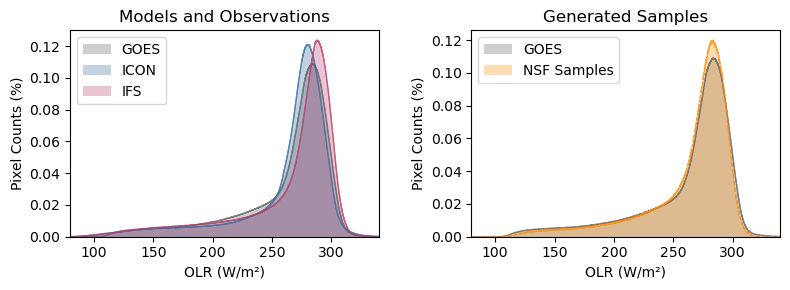

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

HISTOGRAM_RESOLUTION = 0.05 
for dataset, color, order in zip(
    ["goes", "icon", "ifs"], 
    [GOES_COLOR, ICON_COLOR, IFS_COLOR],
    [2, 1, 0]  # plotting order: GOES on top, then ICON, then IFS
):
    hist_data = np.load(f"{histogram_path}/{dataset}_train_histogram.npz")
    hist = hist_data['hist']
    normalised_hist = hist / np.sum(hist)
    bin_edges = hist_data['bin_edges']
    axs[0].bar(bin_edges[:-1], normalised_hist * 100, width=HISTOGRAM_RESOLUTION, color=color, align='edge', alpha=0.3, label=dataset.upper())
    axs[0].step(bin_edges[:-1], normalised_hist * 100, color=color, linestyle='-', linewidth=1, where='post', alpha=0.8)

axs[0].set_xlabel('OLR (W/m²)')
axs[0].set_ylabel('Pixel Counts (%)')
axs[0].set_title('Models and Observations')

xmin = 80
xmax = 340

axs[0].set_xlim(xmin, xmax)
axs[0].legend(loc='upper left')


## plot goes histogram
color = GOES_COLOR
axs[1].bar(bin_edges[:-1], goes_normalised_hist * 100, width=HISTOGRAM_RESOLUTION, color=color, align='edge', alpha=0.3, label='GOES')
axs[1].step(bin_edges[:-1], goes_normalised_hist * 100, color=color, linestyle='-', linewidth=1, where='post', alpha=0.8)


sample_color = 'darkorange'
axs[1].bar(bin_edges[:-1], normalised_sample_hist * 100, width=HISTOGRAM_RESOLUTION, color=sample_color, align='edge', alpha=0.3, label='NSF Samples')
axs[1].step(bin_edges[:-1], normalised_sample_hist * 100, color=sample_color, linestyle='--', linewidth=1, where='post', alpha=0.8)

axs[1].set_xlabel('OLR (W/m²)')
axs[1].set_ylabel('Pixel Counts (%)')
axs[1].set_title('Generated Samples')

axs[1].set_xlim(xmin, xmax)
plt.tight_layout()

axs[1].legend(loc='upper left')

plt.subplots_adjust(wspace=0.3)